In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
df = pd.read_csv("../Data/car_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully!
Shape: (8095, 15)


,city,make,model,variant,mileage,make_year,price,fuel_type,no_of_owners,color,body_type,transmission,registration_year,car_age,make_model
0,delhi-ncr,hyundai,new i20,sportz 1.2 mt dual tone,80637,2021,556000,petrol,1,silver,hatchback,manual,2021,5,hyundai_new i20
1,delhi-ncr,maruti suzuki,vitara brezza,vxi,41189,2021,630000,petrol,2,red,suv,manual,2021,5,maruti suzuki_vitara brezza
2,delhi-ncr,honda,amaze,1.2 s mt petrol,17293,2018,506000,petrol,1,red,sedan,manual,2018,8,honda_amaze
3,delhi-ncr,datsun,redi-go,t,43941,2016,182000,petrol,2,grey,hatchback,manual,2018,10,datsun_redi-go
4,delhi-ncr,hyundai,creta,1.6 sx plus auto petrol,66029,2017,788000,petrol,1,white,suv,automatic,2017,9,hyundai_creta


In [4]:
print("Dataset information:\n")
df.info()

print("\nMissing values:\n")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset information:

<class 'pandas.DataFrame'>
RangeIndex: 8095 entries, 0 to 8094
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   city               8095 non-null   str  
 1   make               8095 non-null   str  
 2   model              8095 non-null   str  
 3   variant            8095 non-null   str  
 4   mileage            8095 non-null   int64
 5   make_year          8095 non-null   int64
 6   price              8095 non-null   int64
 7   fuel_type          8095 non-null   str  
 8   no_of_owners       8095 non-null   int64
 9   color              8095 non-null   str  
 10  body_type          8095 non-null   str  
 11  transmission       8095 non-null   str  
 12  registration_year  8095 non-null   int64
 13  car_age            8095 non-null   int64
 14  make_model         8095 non-null   str  
dtypes: int64(6), str(9)
memory usage: 1.5 MB

Missing values:

city                 0
make         

In [5]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [6]:
df["price"].describe()

count    8.095000e+03
mean     7.319033e+05
std      4.463036e+05
min      1.590000e+05
25%      4.480000e+05
50%      6.227140e+05
75%      8.780000e+05
max      4.039858e+06
Name: price, dtype: float64

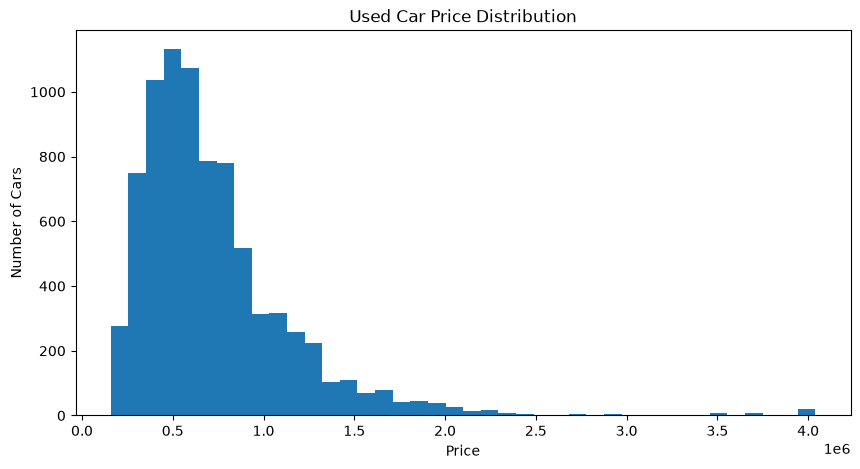

In [7]:
plt.figure(figsize=(10, 5))

plt.hist(df["price"], bins=40)

plt.title("Used Car Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Cars")

plt.show()

In [8]:
numeric_cols = [
    "mileage",
    "make_year",
    "no_of_owners",
    "registration_year",
    "car_age",
    "price"
]

df[numeric_cols].corr()["price"].sort_values(ascending=False)

price                1.000000
registration_year    0.499044
make_year            0.496907
no_of_owners        -0.141503
mileage             -0.203035
car_age             -0.496907
Name: price, dtype: float64

In [9]:
categorical_cols = [
    "fuel_type",
    "transmission",
    "body_type"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


fuel_type
fuel_type
petrol        6796
diesel         873
cng            254
petrol+cng     137
hybrid          35
Name: count, dtype: int64

transmission
transmission
manual       5386
automatic    2709
Name: count, dtype: int64

body_type
body_type
hatchback    3263
suv          2602
sedan        1825
muv           333
crossover      64
wagon           8
Name: count, dtype: int64


In [10]:
for col in ["fuel_type", "transmission", "body_type"]:
    print(f"\nAverage price by {col}:")
    print(
        df.groupby(col)["price"]
        .agg(["count", "mean", "median"])
        .sort_values("mean", ascending=False)
    )


Average price by fuel_type:
            count          mean     median
fuel_type                                 
hybrid         35  1.694554e+06  1690643.0
diesel        873  1.046795e+06   915000.0
petrol       6796  6.969800e+05   598000.0
cng           254  5.616822e+05   557827.0
petrol+cng    137  5.273886e+05   541000.0

Average price by transmission:
              count           mean    median
transmission                                
automatic      2709  945166.589147  794000.0
manual         5386  624638.109915  552000.0

Average price by body_type:
           count          mean     median
body_type                                
wagon          8  3.042483e+06  2928858.0
suv         2602  1.025728e+06   915000.0
muv          333  9.269574e+05   791000.0
sedan       1825  7.326097e+05   615000.0
hatchback   3263  4.771083e+05   458000.0
crossover     64  4.528044e+05   430000.0


In [11]:
print("Number of unique makes:", df["make"].nunique())
print("Number of unique models:", df["model"].nunique())

print("\nTop 15 makes:")
print(df["make"].value_counts().head(15))

print("\nTop 15 models:")
print(df["model"].value_counts().head(15))

Number of unique makes: 21
Number of unique models: 158

Top 15 makes:
make
maruti suzuki    2334
hyundai          1694
honda             885
tata              776
renault           512
kia               382
mahindra          329
ford              271
volkswagen        237
toyota            181
skoda             127
nissan             98
mg motors          75
jeep               55
mercedes-benz      41
Name: count, dtype: int64

Top 15 models:
model
city         425
baleno       397
swift        270
creta        263
kwid         263
grand i10    251
amaze        247
ciaz         238
elite i20    223
venue        222
nexon        207
ecosport     197
seltos       188
tiago        161
sonet        156
Name: count, dtype: int64


In [12]:
print("Unique variants:", df["variant"].nunique())

print("\nTop 20 variants:")
print(df["variant"].value_counts().head(20))

Unique variants: 1293

Top 20 variants:
variant
vxi                          356
sportz 1.2 kappa vtvt        142
lxi                          106
zxi                          106
vxi amt                       92
zxi plus                      77
zeta                          76
zxi amt                       64
sportz 1.2                    64
vx cvt                        63
asta 1.2                      63
zx cvt petrol                 62
lx hard top petrol at 4wd     60
xz plus                       58
v                             56
asta 1.2 kappa vtvt           55
1.6 sx plus auto petrol       49
vxi plus                      49
v petrol                      48
alpha 1.2                     47
Name: count, dtype: int64


In [16]:
expected = (
    df["make"].astype(str).str.strip()
    + "_"
    + df["model"].astype(str).str.strip()
)

print("Matching rows:", (df["make_model"] == expected).sum())
print("Total rows:", len(df))

Matching rows: 8095
Total rows: 8095


In [17]:
df = df.drop(columns=["make_model"])

print("make_model removed.")
print("Remaining columns:", len(df.columns))

make_model removed.
Remaining columns: 14


In [18]:
checks = {
    "mileage <= 0": (df["mileage"] <= 0).sum(),
    "make_year < 1990": (df["make_year"] < 1990).sum(),
    "registration_year < 1990": (df["registration_year"] < 1990).sum(),
    "no_of_owners < 1": (df["no_of_owners"] < 1).sum(),
    "car_age < 0": (df["car_age"] < 0).sum(),
    "price <= 0": (df["price"] <= 0).sum()
}

for name, count in checks.items():
    print(f"{name}: {count}")

mileage <= 0: 0
make_year < 1990: 0
registration_year < 1990: 0
no_of_owners < 1: 0
car_age < 0: 0
price <= 0: 0


In [20]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 6476
Testing rows: 1619


In [21]:
variant_freq = X_train["variant"].value_counts()

X_train = X_train.copy()
X_test = X_test.copy()

X_train["variant"] = X_train["variant"].map(variant_freq)
X_test["variant"] = X_test["variant"].map(variant_freq).fillna(0)

print("Variant encoding completed.")
print("Unique training variants:", X_train["variant"].nunique())
print("Unseen test variants:", (X_test["variant"] == 0).sum())

Variant encoding completed.
Unique training variants: 50
Unseen test variants: 108


In [22]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    "city",
    "make",
    "model",
    "fuel_type",
    "color",
    "body_type",
    "transmission"
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

train_encoded = encoder.fit_transform(X_train[categorical_cols])
test_encoded = encoder.transform(X_test[categorical_cols])

print("Training encoded shape:", train_encoded.shape)
print("Testing encoded shape:", test_encoded.shape)

Training encoded shape: (6476, 225)
Testing encoded shape: (1619, 225)


In [23]:
numerical_cols = [
    "mileage",
    "make_year",
    "no_of_owners",
    "registration_year",
    "car_age",
    "variant"
]

train_numeric = X_train[numerical_cols].to_numpy()
test_numeric = X_test[numerical_cols].to_numpy()

X_train_final = np.hstack([
    train_numeric,
    train_encoded
])

X_test_final = np.hstack([
    test_numeric,
    test_encoded
])

print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)

Final training shape: (6476, 231)
Final testing shape: (1619, 231)


In [24]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_final, y_train)

print("Model training completed.")

Model training completed.


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predictions = model.predict(X_test_final)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"MAE: ₹{mae:,.0f}")
print(f"RMSE: ₹{rmse:,.0f}")
print(f"R² Score: {r2:.4f}")

MAE: ₹44,527
RMSE: ₹88,271
R² Score: 0.9582


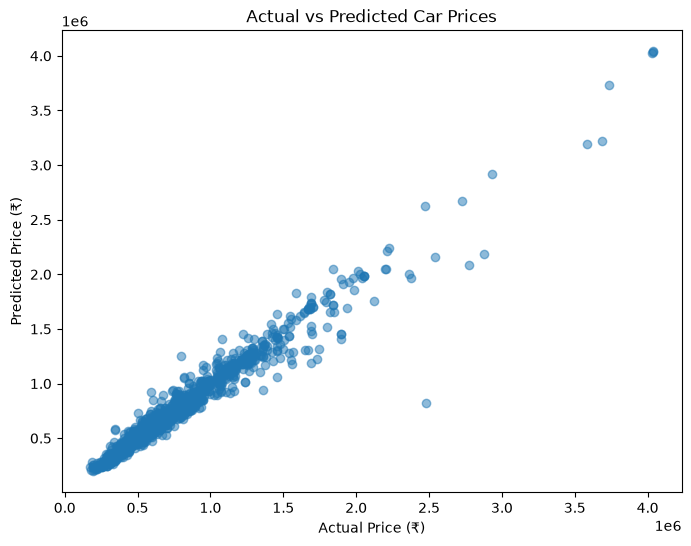

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, predictions, alpha=0.5)

plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")
plt.title("Actual vs Predicted Car Prices")

plt.show()

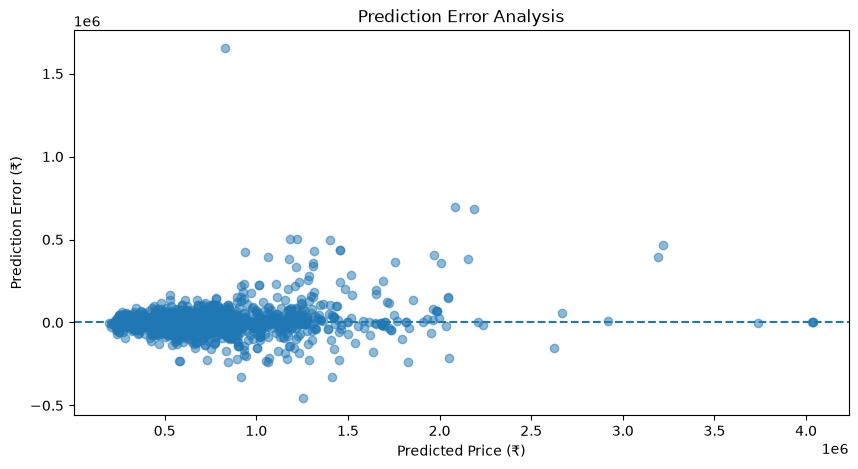

In [27]:
errors = y_test - predictions

plt.figure(figsize=(10, 5))

plt.scatter(predictions, errors, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Price (₹)")
plt.ylabel("Prediction Error (₹)")
plt.title("Prediction Error Analysis")

plt.show()

In [28]:
import os
import joblib

os.makedirs("../Models", exist_ok=True)

joblib.dump(model, "../Models/car_price_model.pkl")
joblib.dump(encoder, "../Models/encoder.pkl")
joblib.dump(variant_freq, "../Models/variant_freq.pkl")

print("Model artifacts saved successfully.")

Model artifacts saved successfully.


In [29]:
def predict_car_price(
    city,
    make,
    model_name,
    variant,
    mileage,
    make_year,
    no_of_owners,
    color,
    body_type,
    transmission,
    registration_year,
    car_age,
    fuel_type
):
    car = pd.DataFrame([{
        "city": city,
        "make": make,
        "model": model_name,
        "variant": variant,
        "mileage": mileage,
        "make_year": make_year,
        "no_of_owners": no_of_owners,
        "color": color,
        "body_type": body_type,
        "transmission": transmission,
        "registration_year": registration_year,
        "car_age": car_age,
        "fuel_type": fuel_type
    }])

    car["variant"] = (
        car["variant"]
        .map(variant_freq)
        .fillna(0)
    )

    train_numeric = car[numerical_cols].to_numpy()

    categorical_data = encoder.transform(car[categorical_cols])

    final_features = np.hstack([
        train_numeric,
        categorical_data
    ])

    return model.predict(final_features)[0]

print("Prediction function ready.")

Prediction function ready.


In [30]:
predicted_price = predict_car_price(
    city="Delhi",
    make="Maruti Suzuki",
    model_name="swift",
    variant="vxi",
    mileage=40000,
    make_year=2020,
    no_of_owners=1,
    color="White",
    body_type="Hatchback",
    transmission="Manual",
    registration_year=2020,
    car_age=5,
    fuel_type="Petrol"
)

print(f"Estimated Car Price: ₹{predicted_price:,.0f}")

Estimated Car Price: ₹862,418
